In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import numpy as np
import pandas as pd
import os
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from sklearn.utils.class_weight import compute_class_weight


In [3]:
train_df = pd.read_csv(
    '/kaggle/input/aptos2019-blindness-detection/train.csv'
)

print(train_df.head())
print(train_df['diagnosis'].value_counts())


        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1
3  002c21358ce6          0
4  005b95c28852          0
diagnosis
0    1805
2     999
1     370
4     295
3     193
Name: count, dtype: int64


In [4]:
train_df['filename'] = train_df['id_code'] + '.png'

print(train_df.head())


        id_code  diagnosis          filename
0  000c1434d8d7          2  000c1434d8d7.png
1  001639a390f0          4  001639a390f0.png
2  0024cdab0c1e          1  0024cdab0c1e.png
3  002c21358ce6          0  002c21358ce6.png
4  005b95c28852          0  005b95c28852.png


In [5]:
train_df['diagnosis'] = train_df['diagnosis'].astype(str)


In [6]:
print(train_df.dtypes)


id_code      object
diagnosis    object
filename     object
dtype: object


In [7]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)


In [8]:
train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory='/kaggle/input/aptos2019-blindness-detection/train_images',
    x_col='filename',
    y_col='diagnosis',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='training',
    shuffle=True
)

val_gen = val_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory='/kaggle/input/aptos2019-blindness-detection/train_images',
    x_col='filename',
    y_col='diagnosis',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='validation',
    shuffle=False
)


Found 2930 validated image filenames belonging to 5 classes.
Found 732 validated image filenames belonging to 5 classes.


In [9]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['diagnosis']),
    y=train_df['diagnosis']
)

class_weights = dict(enumerate(class_weights))
print(class_weights)


{0: np.float64(0.4057617728531856), 1: np.float64(1.9794594594594594), 2: np.float64(0.7331331331331331), 3: np.float64(3.7948186528497407), 4: np.float64(2.4827118644067796)}


In [10]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# freeze toàn bộ backbone
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(5, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.summary()


I0000 00:00:1770137354.365045      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1770137354.367990      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,541 (91.99 MB)

 Trainable params: 525,829 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [11]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [12]:
history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    class_weight=class_weights
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1770137378.055175     125 service.cc:152] XLA service 0x7cc2e404cfd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770137378.055216     125 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1770137378.055220     125 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1770137380.064512     125 cuda_dnn.cc:529] Loaded cuDNN version 91002


 1/92 ━━━━━━━━━━━━━━━━━━━━ 29:06 19s/step - accuracy: 0.2188 - loss: 3.6448

I0000 00:00:1770137386.093762     125 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


92/92 ━━━━━━━━━━━━━━━━━━━━ 533s 6s/step - accuracy: 0.3828 - loss: 1.8640 - val_accuracy: 0.6680 - val_loss: 0.8551
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 371s 4s/step - accuracy: 0.5888 - loss: 1.2390 - val_accuracy: 0.6571 - val_loss: 0.8716
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 371s 4s/step - accuracy: 0.6348 - loss: 1.1284 - val_accuracy: 0.6421 - val_loss: 0.8501
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 366s 4s/step - accuracy: 0.6468 - loss: 1.0386 - val_accuracy: 0.6981 - val_loss: 0.7641
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 364s 4s/step - accuracy: 0.6866 - loss: 0.9953 - val_accuracy: 0.6831 - val_loss: 0.7840
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 365s 4s/step - accuracy: 0.6700 - loss: 1.0046 - val_accuracy: 0.6995 - val_loss: 0.7505
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 364s 4s/step - accuracy: 0.6887 - loss: 0.9281 - val_accuracy: 0.7036 - val_loss: 0.7250
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 367s 4s/step - accuracy: 0.7148 - loss: 0.8971 - val_accuracy: 0.6913 - val_loss: 0.

In [13]:
for layer in base_model.layers[-40:]:
    layer.trainable = True


In [14]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [15]:
history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    class_weight=class_weights
)


Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 398s 4s/step - accuracy: 0.5628 - loss: 1.4101 - val_accuracy: 0.7158 - val_loss: 0.7138
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 366s 4s/step - accuracy: 0.6927 - loss: 0.9425 - val_accuracy: 0.7145 - val_loss: 0.6982
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 364s 4s/step - accuracy: 0.7169 - loss: 0.9501 - val_accuracy: 0.7432 - val_loss: 0.6750
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 368s 4s/step - accuracy: 0.7419 - loss: 0.8068 - val_accuracy: 0.7418 - val_loss: 0.6787
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 369s 4s/step - accuracy: 0.7605 - loss: 0.7507 - val_accuracy: 0.7609 - val_loss: 0.6555
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 366s 4s/step - accuracy: 0.7691 - loss: 0.7502 - val_accuracy: 0.7637 - val_loss: 0.6447
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 366s 4s/step - accuracy: 0.7786 - loss: 0.7184 - val_accuracy: 0.7678 - val_loss: 0.6237
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 366s 4s/step - accuracy: 0.7995 - loss: 0.6592 - val_accuracy: 0.7760 - v

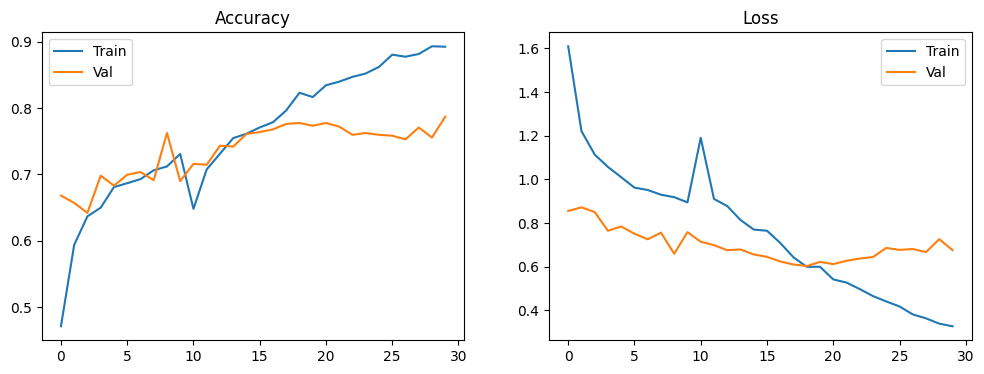

In [16]:
import matplotlib.pyplot as plt

acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss = history1.history['loss'] + history2.history['loss']
val_loss = history1.history['val_loss'] + history2.history['val_loss']

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(acc)
plt.plot(val_acc)
plt.title('Accuracy')
plt.legend(['Train', 'Val'])

plt.subplot(1,2,2)
plt.plot(loss)
plt.plot(val_loss)
plt.title('Loss')
plt.legend(['Train', 'Val'])

plt.show()


In [17]:
model.save("/kaggle/working/resnet_aptos_model.h5")
